# Train Source Ore-Type Segmentation

This notebook trains a multiclass source segmentation model from pre-saved ore masks. It uses 4x-downsampled images and masks from `data_work/source_ore_downsampled`, GPU-side train augmentation, train-set standard scaling, periodic test-loss evaluation, and serial-numbered checkpoints in `models/source_ore_segmentation/<MODEL_SERIAL>`.

In [21]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / 'src').exists():
            PROJECT_ROOT = parent
            break
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tqdm.auto import tqdm

from ore_detection.data.ore_type_legend import load_legend_config
from ore_detection.training.source_ore_dataset import list_source_ore_samples
from ore_detection.training.source_ore_downsample import prepare_downsampled_source_ore_dataset
from ore_detection.training.source_ore_gpu_training import (
    augment_source_ore_batch,
    binary_iou_from_class_index,
    class_index_to_one_hot,
    iter_cached_batches,
    list_downsampled_source_ore_samples,
    load_cached_tensors,
    multiclass_dice,
    normalize_images,
)
from ore_detection.training.const import (
    SOURCE_ORE_DOWNSAMPLE_FACTOR,
    SOURCE_ORE_TRAIN_RGB_MEAN,
    SOURCE_ORE_TRAIN_RGB_STD,
    SOURCE_ORE_TRAIN_STATS_IMAGE_COUNT,
)
from ore_detection.models.simple_unet import create_simple_unet

PROJECT_ROOT

WindowsPath('c:/Users/Cape/PycharmProjects/ore_detection')

In [22]:
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'source_ore_type_legend.json'
DATASETS_ROOT = PROJECT_ROOT / 'datasets'
MASKS_ROOT = PROJECT_ROOT / 'data_work' / 'source_ore_type_masks'
DOWNSAMPLED_ROOT = PROJECT_ROOT / 'data_work' / 'source_ore_downsampled'
MODEL_SERIAL = '001'
MODELS_ROOT = PROJECT_ROOT / 'models' / 'source_ore_segmentation' / MODEL_SERIAL

RUN_DOWNSAMPLE_PREP = False
RUN_TRAINING = False
IMAGE_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 1000
LEARNING_RATE = 1e-4
EVAL_EVERY_N_EPOCHS = 1
DEVICE = 'cuda'
USE_GPU_CACHE = True
USE_GPU_AUGMENTATION = True
PIN_MEMORY = True
NUM_WORKERS = 0
AUG_SCALE_RANGE = (0.5, 2.0)
AUG_BRIGHTNESS_RANGE = (0.8, 1.2)
AUG_CONTRAST_RANGE = (0.8, 1.2)

legend = load_legend_config(CONFIG_PATH)
legend.class_names

('background',
 'chalcopyrite',
 'galena',
 'bornite',
 'pyrite',
 'sphalerite',
 'tennantite_tetrahedrite_group',
 'pyrrhotite',
 'pentlandite',
 'magnetite',
 'arsenopyrite',
 'covellite',
 'hematite',
 'marcasite',
 'native_gold')

Generate the source one-hot masks and downsampled train files before training:

```bash
py -3.13 scripts/convert_source_ore_type_masks.py
py -3.13 scripts/prepare_source_ore_downsampled_dataset.py
```

Set `RUN_DOWNSAMPLE_PREP = True` only when you want this notebook to regenerate `data_work/source_ore_downsampled` and `src/ore_detection/training/const.py`.

In [23]:
source_train_samples = list_source_ore_samples(
    datasets_root=DATASETS_ROOT,
    masks_root=MASKS_ROOT,
    split='train',
)
source_test_samples = list_source_ore_samples(
    datasets_root=DATASETS_ROOT,
    masks_root=MASKS_ROOT,
    split='test',
)
print(f'original train samples: {len(source_train_samples)}')
print(f'original test samples: {len(source_test_samples)}')
print(f'classes: {legend.class_count}')

if RUN_DOWNSAMPLE_PREP:
    prep_summary = prepare_downsampled_source_ore_dataset(
        datasets_root=DATASETS_ROOT,
        masks_root=MASKS_ROOT,
        output_root=DOWNSAMPLED_ROOT,
        const_path=PROJECT_ROOT / 'src' / 'ore_detection' / 'training' / 'const.py',
        factor=SOURCE_ORE_DOWNSAMPLE_FACTOR,
    )
    print(json.dumps(prep_summary, indent=2))
else:
    print('RUN_DOWNSAMPLE_PREP is False; using existing downsampled files.')

original train samples: 134
original test samples: 46
classes: 15
RUN_DOWNSAMPLE_PREP is False; using existing downsampled files.


In [24]:
train_samples = list_downsampled_source_ore_samples(DOWNSAMPLED_ROOT, split='train')
test_samples = list_downsampled_source_ore_samples(DOWNSAMPLED_ROOT, split='test')
print(f'downsampled train samples: {len(train_samples)}')
print(f'downsampled test samples: {len(test_samples)}')
print(f'train RGB mean: {SOURCE_ORE_TRAIN_RGB_MEAN}')
print(f'train RGB std: {SOURCE_ORE_TRAIN_RGB_STD}')
print(f'train stats image count: {SOURCE_ORE_TRAIN_STATS_IMAGE_COUNT}')
if train_samples:
    train_samples[0]

downsampled train samples: 134
downsampled test samples: 46
train RGB mean: (0.4691853836690349, 0.4398698336579204, 0.4024980066350099)
train RGB std: (0.25512571009385043, 0.2335228905839328, 0.2100037541533096)
train stats image count: 134


In [25]:
try:
    import torch
except ModuleNotFoundError:
    torch = None
    print('PyTorch is not installed. Install the ml optional dependencies to train.')

if torch is not None and train_samples:
    preview_device = torch.device('cpu')
    preview_cache = load_cached_tensors(train_samples[: min(2, len(train_samples))], device=preview_device)
    print('preview image', tuple(preview_cache['image'].shape), preview_cache['image'].dtype)
    print('preview class_index', tuple(preview_cache['class_index'].shape), preview_cache['class_index'].dtype)
elif not train_samples:
    print('No downsampled files found. Run scripts/prepare_source_ore_downsampled_dataset.py first.')

preview image (2, 3, 636, 848) torch.float32
preview class_index (2, 636, 848) torch.uint8


In [26]:
def compute_segmentation_loss(model, image, target_class, criterion, *, class_count):
    logits = model(image)
    ce_loss = criterion(logits, target_class)
    target_one_hot = class_index_to_one_hot(target_class, class_count=class_count)
    probs = torch.softmax(logits, dim=1)
    dice_loss = 1 - multiclass_dice(probs, target_one_hot).mean()
    loss = ce_loss + dice_loss
    pred_class = logits.argmax(dim=1)
    iou = binary_iou_from_class_index(pred_class, target_class, background_index=legend.background_index)
    return loss, {
        'loss': float(loss.detach().cpu()),
        'ce_loss': float(ce_loss.detach().cpu()),
        'dice_loss': float(dice_loss.detach().cpu()),
        'binary_iou': float(iou.detach().cpu()),
    }


def mean_metrics(rows):
    if not rows:
        return {'loss': None, 'ce_loss': None, 'dice_loss': None, 'binary_iou': None}
    return {key: sum(row[key] for row in rows) / len(rows) for key in rows[0]}

In [27]:
def train_one_epoch(model, cached, optimizer, criterion, device):
    model.train()
    rows = []
    for batch in iter_cached_batches(cached, batch_size=BATCH_SIZE, shuffle=True):
        image = batch['image'].to(device, non_blocking=True)
        target_class = batch['class_index'].to(device, non_blocking=True)
        if USE_GPU_AUGMENTATION:
            image, target_class = augment_source_ore_batch(
                image,
                target_class,
                output_size=IMAGE_SIZE,
                background_index=legend.background_index,
                scale_range=AUG_SCALE_RANGE,
                brightness_range=AUG_BRIGHTNESS_RANGE,
                contrast_range=AUG_CONTRAST_RANGE,
            )
        image = normalize_images(image, mean=SOURCE_ORE_TRAIN_RGB_MEAN, std=SOURCE_ORE_TRAIN_RGB_STD)

        optimizer.zero_grad(set_to_none=True)
        loss, metrics = compute_segmentation_loss(model, image, target_class, criterion, class_count=legend.class_count)
        loss.backward()
        optimizer.step()
        rows.append(metrics)
    return mean_metrics(rows)


@torch.no_grad()
def evaluate(model, cached, criterion, device):
    model.eval()
    rows = []
    for batch in iter_cached_batches(cached, batch_size=BATCH_SIZE, shuffle=False):
        image = batch['image'].to(device, non_blocking=True)
        target_class = batch['class_index'].to(device, non_blocking=True)
        image = normalize_images(image, mean=SOURCE_ORE_TRAIN_RGB_MEAN, std=SOURCE_ORE_TRAIN_RGB_STD)
        _, metrics = compute_segmentation_loss(model, image, target_class, criterion, class_count=legend.class_count)
        rows.append(metrics)
    return mean_metrics(rows)

In [28]:
def checkpoint_payload(model, optimizer, *, epoch, train_metrics, test_metrics, best_test_loss):
    return {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'best_test_loss': best_test_loss,
        'class_names': legend.class_names,
        'background_index': legend.background_index,
        'image_size': IMAGE_SIZE,
        'learning_rate': LEARNING_RATE,
        'normalization': {
            'mean': SOURCE_ORE_TRAIN_RGB_MEAN,
            'std': SOURCE_ORE_TRAIN_RGB_STD,
            'train_stats_image_count': SOURCE_ORE_TRAIN_STATS_IMAGE_COUNT,
        },
        'augmentation': {
            'use_gpu_augmentation': USE_GPU_AUGMENTATION,
            'scale_range': AUG_SCALE_RANGE,
            'brightness_range': AUG_BRIGHTNESS_RANGE,
            'contrast_range': AUG_CONTRAST_RANGE,
        },
        'notebook': '02_train_source_ore_segmentation.ipynb',
    }

In [29]:
def plot_training_history(history):
    metric_specs = [
        ('loss', 'total loss'),
        ('ce_loss', 'cross entropy loss'),
        ('dice_loss', 'dice loss'),
        ('binary_iou', 'binary ore IoU'),
    ]
    epochs = [row['epoch'] for row in history]
    fig, axes = plt.subplots(len(metric_specs), 1, figsize=(10, 12), sharex=True, constrained_layout=True)
    for axis, (metric_name, title) in zip(axes, metric_specs):
        train_values = [row['train'][metric_name] for row in history]
        test_values = [row['test'][metric_name] if row['test'] is not None else None for row in history]
        axis.plot(epochs, train_values, marker='o', label='train')
        axis.plot(epochs, test_values, marker='o', label='test')
        axis.set_title(title)
        axis.set_ylabel(metric_name)
        axis.grid(True, alpha=0.3)
        axis.legend()
    axes[-1].set_xlabel('epoch')
    plt.show()
    return fig

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

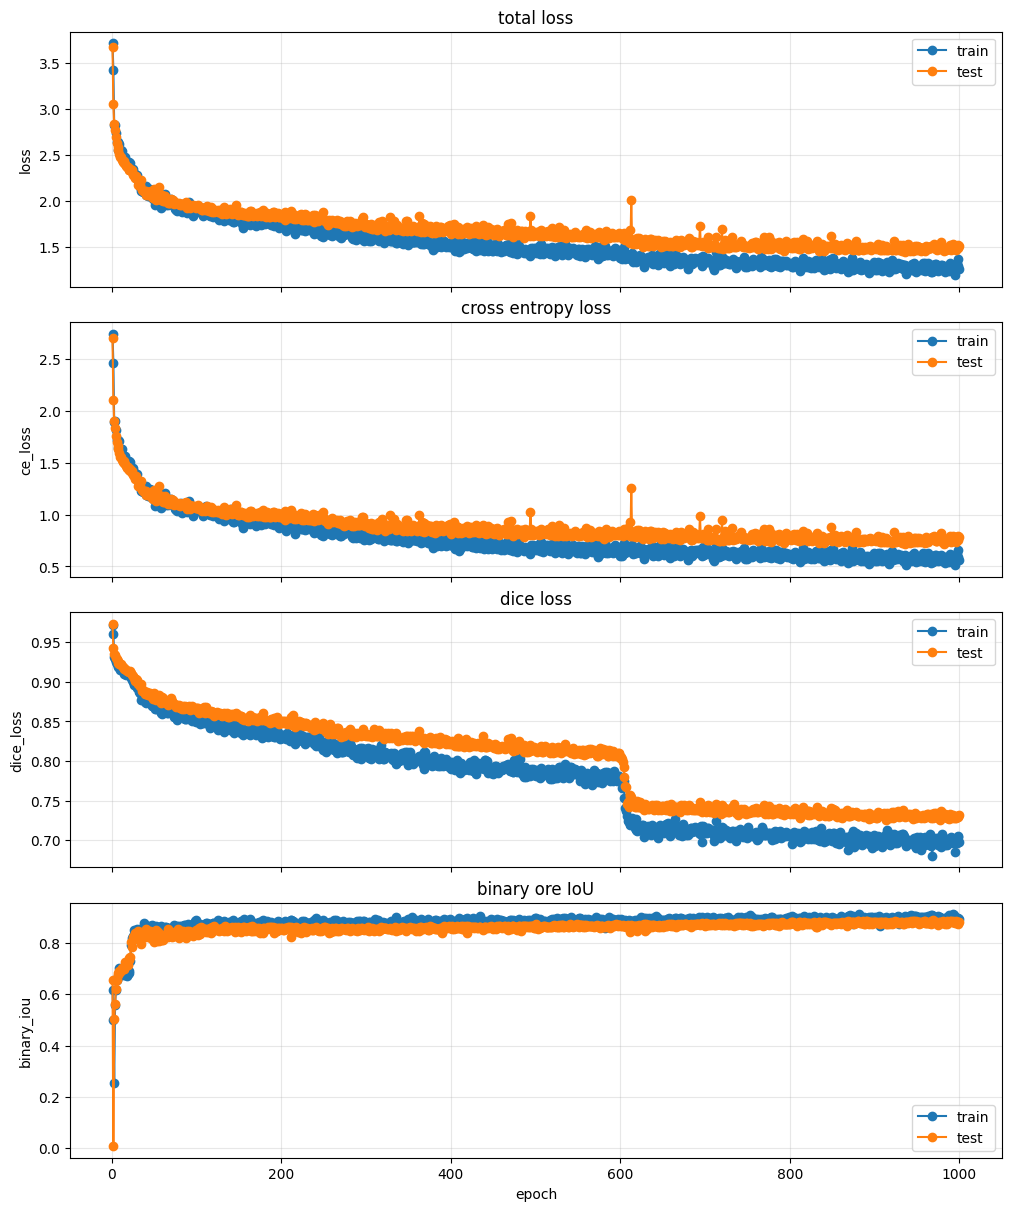

In [30]:
if RUN_TRAINING:
    if torch is None:
        raise RuntimeError('PyTorch is required for training.')
    if not train_samples:
        raise RuntimeError('No downsampled train files found. Run scripts/prepare_source_ore_downsampled_dataset.py first.')
    if not test_samples:
        raise RuntimeError('No downsampled test files found. Run scripts/prepare_source_ore_downsampled_dataset.py first.')
    if SOURCE_ORE_TRAIN_STATS_IMAGE_COUNT == 0:
        raise RuntimeError('Train RGB stats are empty. Run scripts/prepare_source_ore_downsampled_dataset.py first.')

    device = torch.device(DEVICE if DEVICE == 'cuda' and torch.cuda.is_available() else 'cpu')
    if device.type == 'cuda':
        torch.backends.cudnn.benchmark = True
    cache_device = device if USE_GPU_CACHE and device.type == 'cuda' else torch.device('cpu')
    use_pin_memory = PIN_MEMORY and cache_device.type == 'cpu' and device.type == 'cuda'

    MODELS_ROOT.mkdir(parents=True, exist_ok=True)
    train_cache = load_cached_tensors(train_samples, device=cache_device, pin_memory=use_pin_memory)
    test_cache = load_cached_tensors(test_samples, device=cache_device, pin_memory=use_pin_memory)

    model = create_simple_unet(out_channels=legend.class_count).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = torch.nn.CrossEntropyLoss()

    history = []
    best_test_loss = float('inf')
    with tqdm(range(1, EPOCHS + 1), desc='Training') as pbar:
        for epoch in pbar:
            train_metrics = train_one_epoch(model, train_cache, optimizer, criterion, device)
            test_metrics = None
            if epoch % EVAL_EVERY_N_EPOCHS == 0 or epoch == EPOCHS:
                test_metrics = evaluate(model, test_cache, criterion, device)

            row = {'epoch': epoch, 'train': train_metrics, 'test': test_metrics}
            history.append(row)
            postfix = {
                'train_loss': f"{train_metrics['loss']:.4f}",
                'train_iou': f"{train_metrics['binary_iou']:.4f}",
            }
            if test_metrics is not None:
                postfix['test_loss'] = f"{test_metrics['loss']:.4f}"
                postfix['test_iou'] = f"{test_metrics['binary_iou']:.4f}"
            pbar.set_postfix(postfix)

            torch.save(
                checkpoint_payload(
                    model,
                    optimizer,
                    epoch=epoch,
                    train_metrics=train_metrics,
                    test_metrics=test_metrics,
                    best_test_loss=best_test_loss,
                ),
                MODELS_ROOT / 'last.pt',
            )
            if test_metrics is not None and test_metrics['loss'] < best_test_loss:
                best_test_loss = test_metrics['loss']
                torch.save(
                    checkpoint_payload(
                        model,
                        optimizer,
                        epoch=epoch,
                        train_metrics=train_metrics,
                        test_metrics=test_metrics,
                        best_test_loss=best_test_loss,
                    ),
                    MODELS_ROOT / 'best.pt',
                )
            (MODELS_ROOT / 'history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')
    plot_training_history(history)
else:
    print('RUN_TRAINING is False; set it to True after downsample preparation and environment checks.')